# ROMS Doppio Access Benchmarks
Revised August 18, 2026 by Sage Lichtenwalner

This notebook includes several benchmark test to highlight different strategirs for accessing ROMS Doppio data from the Rutgers Threadds data server.  The Thredds server provides easy access to the large model dataset, however, data requests for large areas or time periods are not possible due to the limitations of processing on the Thredds site.

In [10]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from erddapy import ERDDAP
import time

## Setup ROMS Dataset

In [11]:
doppio_url = 'https://tds.marine.rutgers.edu/thredds/dodsC/roms/doppio/2017_da/his/History_Best'
ds = xr.open_dataset(doppio_url)
ds

<xarray.Dataset> Size: 7TB
Dimensions:         (time: 77196, time1: 77196, time2: 480, time3: 77196,
                     tracer: 2, boundary: 4, s_rho: 40, s_w: 41, eta_rho: 106,
                     xi_rho: 242, eta_u: 106, xi_u: 241, eta_v: 105, xi_v: 242,
                     eta_psi: 105, xi_psi: 241, ocean_time: 24)
Coordinates: (12/18)
  * time            (time) datetime64[ns] 618kB 2017-11-02T01:00:00 ... 2026-...
    time_run        (time) datetime64[ns] 618kB ...
  * time1           (time1) datetime64[ns] 618kB 2017-11-02T01:00:00 ... 2026...
    time1_run       (time1) datetime64[ns] 618kB ...
  * time2           (time2) datetime64[ns] 4kB 2023-06-30T01:00:00 ... 2024-1...
  * time3           (time3) datetime64[ns] 618kB 2017-11-02T01:00:00 ... 2026...
    ...              ...
    lat_u           (eta_u, xi_u) float64 204kB ...
    lon_v           (eta_v, xi_v) float64 203kB ...
    lat_v           (eta_v, xi_v) float64 203kB ...
    lon_psi         (eta_psi, xi_psi) float64 202kB ...
    lat_psi         (eta_psi, xi_psi) float64 202kB ...
  * ocean_time      (ocean_time) datetime64[ns] 192B 2026-08-14T01:00:00 ... ...
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/123)
    time_offset     (time) datetime64[ns] 618kB ...
    time1_offset    (time1) datetime64[ns] 618kB ...
    time2_run       (time2) datetime64[ns] 4kB ...
    time2_offset    (time2) datetime64[ns] 4kB ...
    time3_offset    (time3) datetime64[ns] 618kB ...
    ntimes          int32 4B ...
    ...              ...
    sustr           (time1, eta_u, xi_u) float64 16GB ...
    svstr           (time1, eta_v, xi_v) float64 16GB ...
    v_northward_1m  (time, eta_rho, xi_rho) float64 16GB ...
    u_eastward_1m   (time, eta_rho, xi_rho) float64 16GB ...
    Vwind           (time, eta_rho, xi_rho) float64 16GB ...
    Uwind           (time, eta_rho, xi_rho) float64 16GB ...
Attributes: (12/49)
    file:                            doppio_his_7526.nc
    format:                          netCDF-4/HDF5 file
    Conventions:                     CF-1.4, SGRID-0.3
    type:                            ROMS/TOMS history file
    title:                           ROMS doppio Real-Time Operational PSAS F...
    var_info:                        ../Data/varinfo1040t_daily.dat
    ...                              ...
    cdm_data_type:                   GRID
    featureType:                     GRID
    location:                        Proto fmrc:doppio_2017_da_his
    summary:                         doppio
    DODS_EXTRA.Unlimited_Dimension:  ocean_time
    EXTRA_DIMENSION.N:               40

## Benchmark testing
Fpr testing purposes, we will define a single grid point to extract.

In [12]:
eta_idx = 40 
xi_idx = 39

In [13]:
# Benchmark settings
end = pd.Timestamp("2024-01-01")
windows = [
    ("1 day", pd.Timedelta(days=1)),
    ("1 week", pd.Timedelta(weeks=1)),
    ("2 weeks", pd.Timedelta(weeks=2)),
    ("1 month", pd.DateOffset(months=1)),
    ("2 months", pd.DateOffset(months=2)),
    ("3 months", pd.DateOffset(months=3)),
    # ("6 months", pd.DateOffset(months=6)),
    # ("9 months", pd.DateOffset(months=9)),
    # ("12 months", pd.DateOffset(months=12)),
]

rows = []
n_windows = len(windows)

print(f"Starting benchmark: {n_windows} windows, 1 run each")
print("Comparing: single-point (fixed s_rho) vs full profile (all s_rho)")

for i, (label, delta) in enumerate(windows, start=1):
    start = end - delta

    print(f"\n[{i}/{n_windows}] Window: {label} ({start:%Y-%m-%d} to {end:%Y-%m-%d})")

    t0 = time.perf_counter()
    arr_point = ds["temp"].sel(
        time=slice(start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")),
        s_rho=ds["s_rho"].min(),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()
    point_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    arr_profile = ds["temp"].sel(
        time=slice(start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()
    profile_s = time.perf_counter() - t1

    n_time = arr_point.sizes.get("time", None)
    n_levels = arr_profile.sizes.get("s_rho", None)

    point_bytes = int(arr_point.nbytes)
    profile_bytes = int(arr_profile.nbytes)

    profile_over_point_time = (profile_s / point_s) if point_s > 0 else float("nan")
    profile_over_point_size = (profile_bytes / point_bytes) if point_bytes > 0 else float("nan")

    rows.append(
        {
            "window": label,
            "months": (end.to_period("M") - start.to_period("M")).n + (0 if label in ["1 day", "1 week"] else 0),
            "start": start.strftime("%Y-%m-%d"),
            "end": end.strftime("%Y-%m-%d"),
            "n_time": n_time,
            "n_levels": n_levels,
            "point_s": point_s,
            "profile_s": profile_s,
            "profile_over_point_time": profile_over_point_time,
            # "point_bytes": point_bytes,
            # "profile_bytes": profile_bytes,
            "point_mb": point_bytes / 1e6,
            "profile_mb": profile_bytes / 1e6,
            "profile_over_point_size": profile_over_point_size,
        }
    )

    print(
        f"  point={point_s:.4f}s ({point_bytes/1e6:.3f} MB), "
        f"profile={profile_s:.4f}s ({profile_bytes/1e6:.3f} MB), "
        f"time ratio={profile_over_point_time:.2f}x, "
        f"size ratio={profile_over_point_size:.2f}x"
    )

bench = pd.DataFrame(rows)

print("\nRun complete. Use next cells for analysis table and plot.")

Starting benchmark: 6 windows, 1 run each
Comparing: single-point (fixed s_rho) vs full profile (all s_rho)

[1/6] Window: 1 day (2023-12-31 to 2024-01-01)
  point=0.6247s (0.000 MB), profile=0.8502s (0.015 MB), time ratio=1.36x, size ratio=40.00x

[2/6] Window: 1 week (2023-12-25 to 2024-01-01)
  point=1.3648s (0.002 MB), profile=2.3866s (0.061 MB), time ratio=1.75x, size ratio=40.00x

[3/6] Window: 2 weeks (2023-12-18 to 2024-01-01)
  point=2.2606s (0.003 MB), profile=4.0667s (0.115 MB), time ratio=1.80x, size ratio=40.00x

[4/6] Window: 1 month (2023-12-01 to 2024-01-01)
  point=4.4061s (0.006 MB), profile=8.2616s (0.246 MB), time ratio=1.88x, size ratio=40.00x

[5/6] Window: 2 months (2023-11-01 to 2024-01-01)
  point=8.2349s (0.012 MB), profile=15.6962s (0.476 MB), time ratio=1.91x, size ratio=40.00x

[6/6] Window: 3 months (2023-10-01 to 2024-01-01)
  point=12.1678s (0.018 MB), profile=23.5014s (0.714 MB), time ratio=1.93x, size ratio=40.00x

Run complete. Use next cells for anal

In [14]:
bench

,window,months,start,end,n_time,n_levels,point_s,profile_s,profile_over_point_time,point_mb,profile_mb,profile_over_point_size
0,1 day,1,2023-12-31,2024-01-01,48,40,0.624702,0.850172,1.360925,0.000384,0.01536,40.0
1,1 week,1,2023-12-25,2024-01-01,192,40,1.364789,2.386602,1.748697,0.001536,0.06144,40.0
2,2 weeks,1,2023-12-18,2024-01-01,360,40,2.260572,4.066674,1.798958,0.002880,0.11520,40.0
3,1 month,1,2023-12-01,2024-01-01,768,40,4.406112,8.261576,1.875026,0.006144,0.24576,40.0
4,2 months,2,2023-11-01,2024-01-01,1488,40,8.234871,15.696173,1.906062,0.011904,0.47616,40.0
5,3 months,3,2023-10-01,2024-01-01,2232,40,12.167834,23.501379,1.931435,0.017856,0.71424,40.0


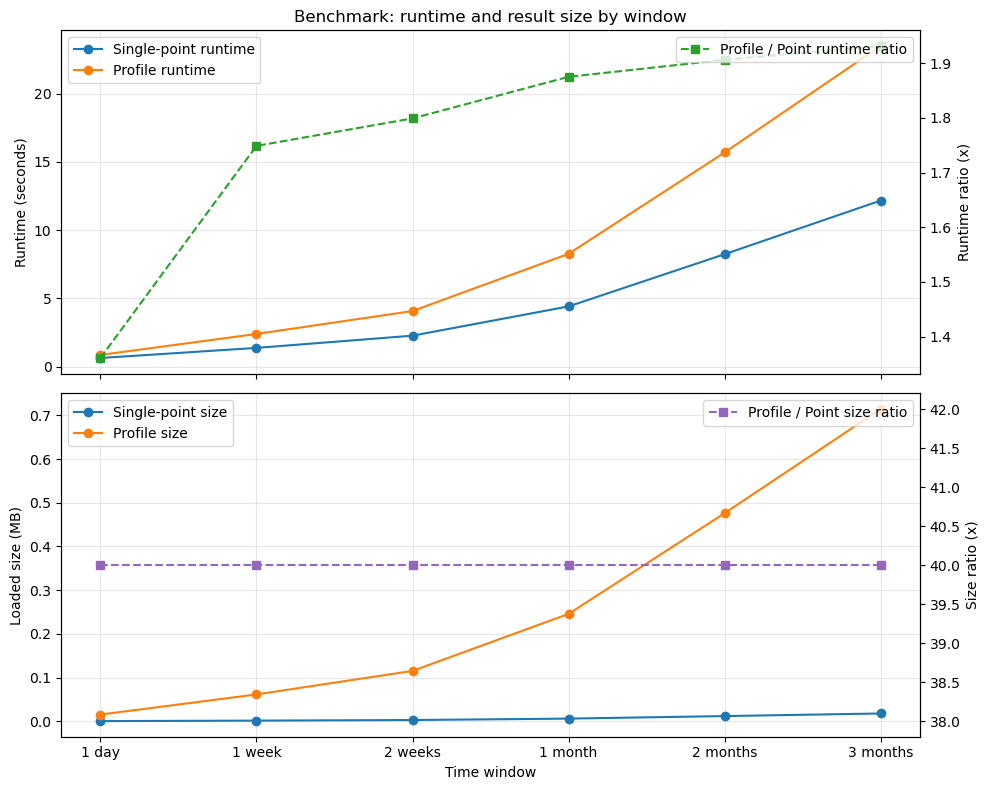

In [15]:
bench_plot = bench.reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Runtime comparison
axes[0].plot(bench_plot["window"], bench_plot["point_s"], marker="o", label="Single-point runtime")
axes[0].plot(bench_plot["window"], bench_plot["profile_s"], marker="o", label="Profile runtime")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Benchmark: runtime and result size by window")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left")

ax0r = axes[0].twinx()
ax0r.plot(
    bench_plot["window"],
    bench_plot["profile_over_point_time"],
    marker="s",
    linestyle="--",
    color="tab:green",
    label="Profile / Point runtime ratio",
)
ax0r.set_ylabel("Runtime ratio (x)")
ax0r.legend(loc="upper right")

# Size comparison
axes[1].plot(bench_plot["window"], bench_plot["point_mb"], marker="o", label="Single-point size")
axes[1].plot(bench_plot["window"], bench_plot["profile_mb"], marker="o", label="Profile size")
axes[1].set_ylabel("Loaded size (MB)")
axes[1].set_xlabel("Time window")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper left")

ax1r = axes[1].twinx()
ax1r.plot(
    bench_plot["window"],
    bench_plot["profile_over_point_size"],
    marker="s",
    linestyle="--",
    color="tab:purple",
    label="Profile / Point size ratio",
)
ax1r.set_ylabel("Size ratio (x)")
ax1r.legend(loc="upper right")

plt.tight_layout()
plt.show()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
fig.savefig(f"images/roms_benchmark_runtime_{timestamp}.png", dpi=300, bbox_inches="tight")

## Sequential load test

In [16]:
import time
import numpy as np
import pandas as pd
import xarray as xr

# Compare load strategies over a configurable time window at the selected ROMS point.
test_start = pd.Timestamp("2024-01-01")
test_end = pd.Timestamp("2024-04-01")

# Configure chunk plans here. Use None for one-shot load.
# Examples: "5D", "10D", "2W", "MS", "2MS", pd.Timedelta(days=3)
chunk_plan = [
    ("all_at_once", None),
    ("monthly_chunks", "MS"),
    ("5day_chunks", "5D"),
    ("1day_chunks", "1D"),
]

print(f"Chunking test window: {test_start:%Y-%m-%d} to {test_end:%Y-%m-%d} ({(test_end - test_start).days} days)")

def load_temp_profile(start_ts, end_ts):
    return ds["temp"].sel(
        time=slice(start_ts.strftime("%Y-%m-%d"), end_ts.strftime("%Y-%m-%d")),
        eta_rho=eta_idx,
        xi_rho=xi_idx,
    ).load()

def build_ranges(start_ts, end_ts, chunk_spec):
    if chunk_spec is None:
        return [(start_ts, end_ts)]

    boundaries = pd.date_range(start=start_ts, end=end_ts, freq=chunk_spec)
    if len(boundaries) == 0 or boundaries[0] != start_ts:
        boundaries = boundaries.insert(0, start_ts)
    if boundaries[-1] != end_ts:
        boundaries = boundaries.insert(len(boundaries), end_ts)

    return list(zip(boundaries[:-1], boundaries[1:]))

def run_strategy(label, ranges):
    chunk_times = []
    pieces = []
    print(f"\nRunning strategy: {label} ({len(ranges)} chunk(s))")

    t0_total = time.perf_counter()
    for idx, (chunk_start, chunk_end) in enumerate(ranges, start=1):
        print(f"  chunk {idx}/{len(ranges)}: {chunk_start:%Y-%m-%d} to {chunk_end:%Y-%m-%d}")
        t0_chunk = time.perf_counter()
        pieces.append(load_temp_profile(chunk_start, chunk_end))
        chunk_times.append(time.perf_counter() - t0_chunk)

    if len(pieces) == 1:
        result = pieces[0]
    else:
        result = xr.concat(pieces, dim="time").sortby("time")
        _, unique_idx = np.unique(result["time"].values, return_index=True)
        result = result.isel(time=np.sort(unique_idx))

    total_s = time.perf_counter() - t0_total
    chunk_mean_s = float(np.mean(chunk_times))
    chunk_std_s = float(np.std(chunk_times)) if len(chunk_times) > 1 else 0.0
    size_mb = result.nbytes / 1e6

    print(
        f"  done: total={total_s:.3f}s, "
        f"chunk_mean={chunk_mean_s:.3f}s, chunk_std={chunk_std_s:.3f}s, "
        f"size={size_mb:.3f} MB"
    )

    return {
        "strategy": label,
        "total_s": total_s,
        "chunk_mean_s": chunk_mean_s,
        "chunk_std_s": chunk_std_s,
        "size_mb": size_mb,
    }, result

summary_rows = []
results_by_strategy = {}

for strategy_label, chunk_spec in chunk_plan:
    ranges = build_ranges(test_start, test_end, chunk_spec)
    row, arr = run_strategy(strategy_label, ranges)
    summary_rows.append(row)
    results_by_strategy[strategy_label] = arr

chunk_compare = pd.DataFrame(summary_rows).sort_values("strategy").reset_index(drop=True)

print("\nRun complete. Use next cells for analysis table and plot.")

Chunking test window: 2024-01-01 to 2024-04-01 (91 days)

Running strategy: all_at_once (1 chunk(s))
  chunk 1/1: 2024-01-01 to 2024-04-01
  done: total=23.023s, chunk_mean=23.023s, chunk_std=0.000s, size=0.707 MB

Running strategy: monthly_chunks (3 chunk(s))
  chunk 1/3: 2024-01-01 to 2024-02-01
  chunk 2/3: 2024-02-01 to 2024-03-01
  chunk 3/3: 2024-03-01 to 2024-04-01
  done: total=24.151s, chunk_mean=8.047s, chunk_std=0.251s, size=0.707 MB

Running strategy: 5day_chunks (19 chunk(s))
  chunk 1/19: 2024-01-01 to 2024-01-06
  chunk 2/19: 2024-01-06 to 2024-01-11
  chunk 3/19: 2024-01-11 to 2024-01-16
  chunk 4/19: 2024-01-16 to 2024-01-21
  chunk 5/19: 2024-01-21 to 2024-01-26
  chunk 6/19: 2024-01-26 to 2024-01-31
  chunk 7/19: 2024-01-31 to 2024-02-05
  chunk 8/19: 2024-02-05 to 2024-02-10
  chunk 9/19: 2024-02-10 to 2024-02-15
  chunk 10/19: 2024-02-15 to 2024-02-20
  chunk 11/19: 2024-02-20 to 2024-02-25
  chunk 12/19: 2024-02-25 to 2024-03-01
  chunk 13/19: 2024-03-01 to 2024-0

In [17]:
# Analysis table
display(
    chunk_compare[["strategy", "total_s", "chunk_mean_s", "chunk_std_s", "size_mb"]].round(4)
)

,strategy,total_s,chunk_mean_s,chunk_std_s,size_mb
0,1day_chunks,77.2001,0.8474,0.0089,0.7066
1,5day_chunks,33.7599,1.7755,0.2190,0.7066
2,all_at_once,23.0234,23.0233,0.0000,0.7066
3,monthly_chunks,24.1510,8.0474,0.2508,0.7066


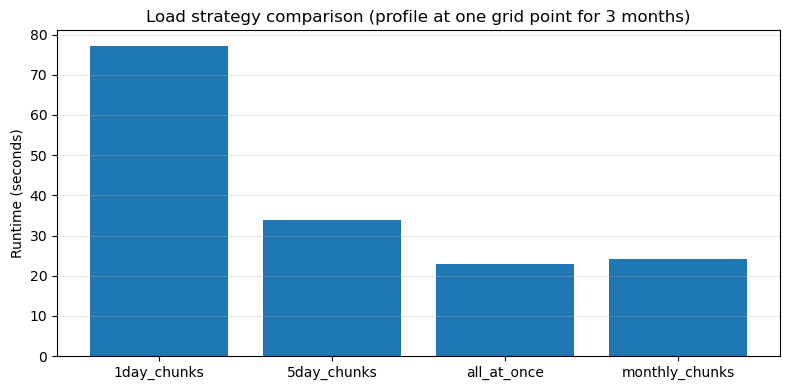

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(chunk_compare["strategy"], chunk_compare["total_s"])
ax.set_ylabel("Runtime (seconds)")
ax.set_title("Load strategy comparison (profile at one grid point for 3 months)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
fig.savefig(f"images/roms_benchmark_strategy_{timestamp}.png", dpi=300, bbox_inches="tight")